#  Optuna for Quantum Machine Learning Demonstration

This notebook demonstrates hyperparameter optimization using Optuna for a quantum machine learning task
implemented with PennyLane. The objective is to optimize the hyperparameters of a simple quantum binary
classification model.



In [1]:
# Setup
!pip install optuna pennylane matplotlib scikit-learn torch -q

import torch
import torch.nn.functional as F
import optuna
import pennylane as qml
import pennylane.numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:

# Check Library Versions
import sys
print(f"Python version: {sys.version}")
print(f"PennyLane version: {qml.__version__}")
print(f"Optuna version: {optuna.__version__}")


Python version: 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:40:08) [MSC v.1938 64 bit (AMD64)]
PennyLane version: 0.37.0
Optuna version: 4.1.0


In [3]:

# Quantum Machine Learning Task - Dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:

# Quantum Circuit
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def circuit(params, x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    qml.BasicEntanglerLayers(params, wires=range(n_qubits))



In [5]:

# Quantum Model
def create_model(n_layers):
    @qml.qnode(dev, interface="torch")
    def quantum_model(params, x):
        for i in range(n_layers):
            circuit(params[i], x)
        return qml.probs(wires=0)
    return quantum_model

def predict(model, params, X):
    return torch.stack([model(params, x)[0] for x in X])


In [ ]:

# Hyperparameter Optimization
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 5)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True)

    quantum_model = create_model(n_layers)
    params = torch.randn(n_layers, 1, n_qubits)
    params.requires_grad = True
    optimizer = torch.optim.Adam([params], learning_rate)

    batch_size = 32
    for i in range(0, len(X_train), batch_size):
        X_batch = torch.from_numpy(X_train[i:i + batch_size])
        y_true_batch = torch.from_numpy(y_train[i:i + batch_size])

        y_pred = predict(quantum_model, params, X_batch)
        optimizer.zero_grad()
        loss = F.binary_cross_entropy(y_pred.float(), y_true_batch.float())
        loss.backward()
        optimizer.step()

    y_pred = predict(quantum_model, params, torch.from_numpy(X_test))
    return F.binary_cross_entropy(y_pred.float(), torch.from_numpy(y_test).float())

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)


[I 2024-12-06 21:47:44,253] A new study created in memory with name: no-name-a3d28a6f-44bb-4482-a7e2-60b50eff3fb4
[I 2024-12-06 21:47:47,111] Trial 0 finished with value: 0.7529433965682983 and parameters: {'n_layers': 2, 'learning_rate': 0.014199313641768158}. Best is trial 0 with value: 0.7529433965682983.
[I 2024-12-06 21:47:49,212] Trial 1 finished with value: 0.5358585119247437 and parameters: {'n_layers': 4, 'learning_rate': 0.003037621740397081}. Best is trial 1 with value: 0.5358585119247437.
[I 2024-12-06 21:47:50,356] Trial 2 finished with value: 0.8739330172538757 and parameters: {'n_layers': 2, 'learning_rate': 0.0012084627159249291}. Best is trial 1 with value: 0.5358585119247437.
[I 2024-12-06 21:47:51,962] Trial 3 finished with value: 0.7745396494865417 and parameters: {'n_layers': 3, 'learning_rate': 0.004524247549198947}. Best is trial 1 with value: 0.5358585119247437.
[I 2024-12-06 21:47:54,573] Trial 4 finished with value: 0.7563549280166626 and parameters: {'n_layer

C:\Users\USER\AppData\Local\Temp\ipykernel_36704\2920525061.py:4: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


Best Hyperparameters: {'n_layers': 5, 'learning_rate': 0.09680819216509234}


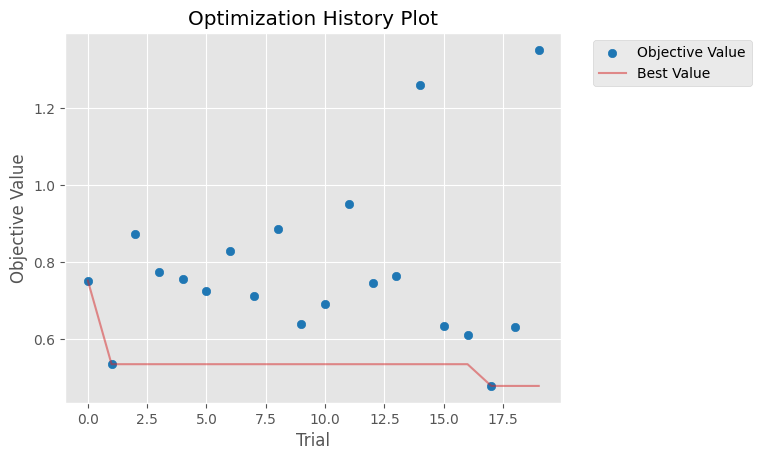

C:\Users\USER\AppData\Local\Temp\ipykernel_36704\2920525061.py:7: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


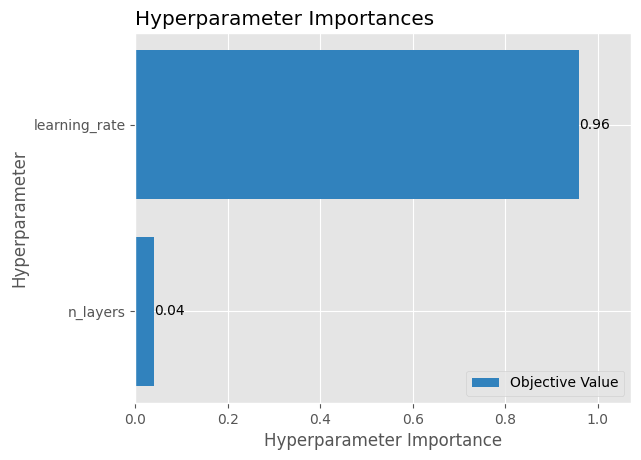

In [7]:

# Results Visualization
print("Best Hyperparameters:", study.best_params)

optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()


In [ ]:

# Evaluation
best_params = study.best_params
n_layers = best_params['n_layers']
learning_rate = best_params['learning_rate']

quantum_model = create_model(n_layers)
params = torch.randn(n_layers, 1, n_qubits)
params.requires_grad = True
optimizer = torch.optim.Adam([params], learning_rate)

batch_size = 32
for i in range(0, len(X_train), batch_size):
    X_batch = torch.from_numpy(X_train[i:i + batch_size])
    y_true_batch = torch.from_numpy(y_train[i:i + batch_size])

    y_pred = predict(quantum_model, params, X_batch)
    optimizer.zero_grad()
    loss = F.binary_cross_entropy(y_pred.float(), y_true_batch.float())
    loss.backward()
    optimizer.step()

y_pred = predict(quantum_model, params, torch.from_numpy(X_test))

loss = F.binary_cross_entropy(y_pred.float(), torch.from_numpy(y_test).float())
accuracy = torch.mean(((y_pred > 0.5) == y_test).float())

print(f"Test Loss: {loss.item():.4f}")
print(f"Test Accuracy: {accuracy.item():.2%}")



Test Loss: 0.6396
Test Accuracy: 62.50%
